In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

import seaborn as sns

import matplotlib
%matplotlib inline

import glob

In [67]:
df = pd.read_csv('../data/years_season_EFscale.csv', index_col=0)
dfall = pd.read_csv('../data/tornadoes_all.csv', index_col=0)

In [68]:
dfall

,YEAR,MONTH,BEGIN_LAT,BEGIN_LON,TOR_F_SCALE
0,1990,6,44.3700,-92.6300,1
1,1990,5,42.0800,-71.4000,0
2,1990,6,41.1000,-98.4700,0
3,1990,6,41.5200,-97.7300,0
4,1990,6,40.2500,-100.7500,4
...,...,...,...,...,...
48229,2025,9,48.2490,-100.8390,-1
48230,2025,6,37.2391,-98.0398,0
48231,2025,9,47.1400,-100.1750,-1
48232,2025,6,36.1732,-101.1485,2


In [69]:
df

,year,EF0,EF1,EF2,EF3,EF4,EF5,Nspring,Nsummer,Nautumn,Nwinter
0,1990,541,412,190,71,42,8,329,235,73,86
1,1991,694,313,128,61,10,2,360,91,40,23
2,1992,707,447,151,67,30,2,119,321,219,38
3,1993,242,134,37,7,3,0,92,27,45,17
4,1994,381,144,42,10,4,0,76,89,31,4
5,1995,478,168,57,13,9,0,147,50,32,18
6,1996,765,341,102,26,3,1,225,118,97,33
7,1997,756,294,89,31,9,1,169,131,75,49
8,1998,914,416,137,48,11,3,271,189,94,61
9,1999,885,381,164,69,16,2,311,135,24,162


###  Reference for trends over longer period of time: https://repository.library.noaa.gov/view/noaa/69284 

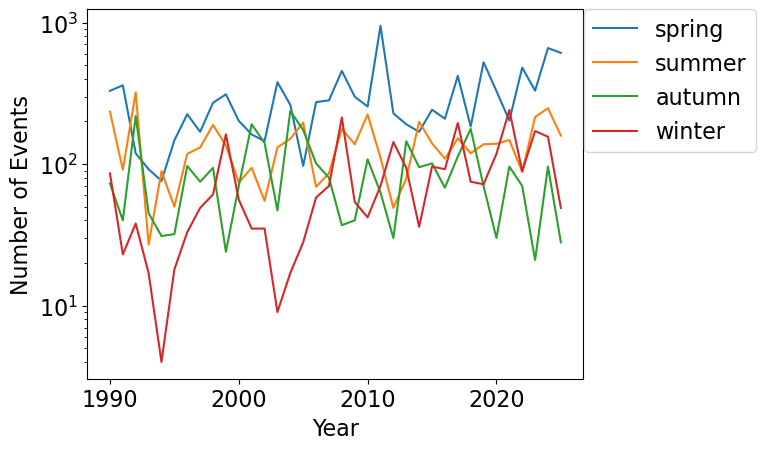

In [70]:
plt.figure()
plt.plot(df.year, df.Nspring, label='spring')
plt.plot(df.year, df.Nsummer, label='summer')
plt.plot(df.year, df.Nautumn, label='autumn')
plt.plot(df.year, df.Nwinter, label='winter')
plt.xlabel('Year')
plt.legend(loc='upper right', bbox_to_anchor=(1.37, 1.03))
plt.ylabel('Number of Events')
plt.yscale('log')

Text(0, 0.5, 'Number of Events')

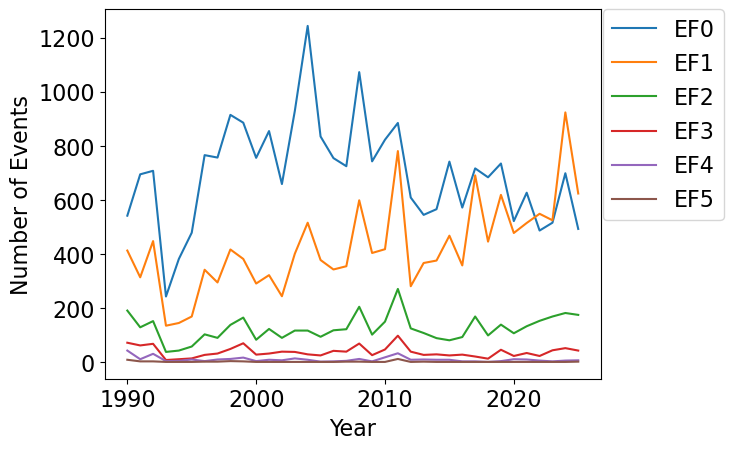

In [71]:
plt.figure()
plt.plot(df.year, df.EF0, label='EF0')
plt.plot(df.year, df.EF1, label='EF1')
plt.plot(df.year, df.EF2, label='EF2')
plt.plot(df.year, df.EF3, label='EF3')
plt.plot(df.year, df.EF4, label='EF4')
plt.plot(df.year, df.EF5, label='EF5')
plt.legend(loc='upper right', bbox_to_anchor=(1.27, 1.03))
plt.xlabel('Year')
plt.ylabel('Number of Events')

In [72]:
# feature engineering -- the log of events shows a clearer overall trend
df.Nspring = np.log10(df.Nspring)

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

parametric_model = LinearRegression()
parametric_model.fit(np.array(df.year).reshape(-1,1), df.Nspring)
parametric_predictions = parametric_model.predict(np.array(df.year).reshape(-1,1))
parametric_mse = mean_squared_error(df.Nspring, parametric_predictions)
print(parametric_mse)

0.043178621533946276


In [81]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

nonparametric_model = KernelRidge(kernel='rbf')
param_grid = {"alpha":    [10**(-k) for k in range(-5, 5)],
              "gamma": [10**(k) for k in range(-5,5)]}

search = GridSearchCV(nonparametric_model, param_grid, cv=5).fit(np.array(df.year).reshape(-1,1), df.Nspring)

print("The best hyperparameters are ",search.best_params_)

The best hyperparameters are  {'alpha': 0.01, 'gamma': 1e-05}


In [82]:
nonparametric_model = KernelRidge(kernel = 'rbf', **search.best_params_) # ** "unpacks" the dict of params into kwarg assignments
nonparametric_model.fit(np.array(df.year).reshape(-1,1), df.Nspring)
nonparametric_predictions = nonparametric_model.predict(np.array(df.year).reshape(-1,1))
nonparametric_mse = mean_squared_error(df.Nspring, nonparametric_predictions)
print(nonparametric_mse)

0.04347881485839786


### The linear regression and non-parametric model both have large MSE's, likely due to the extreme number of tornadoes in 2011

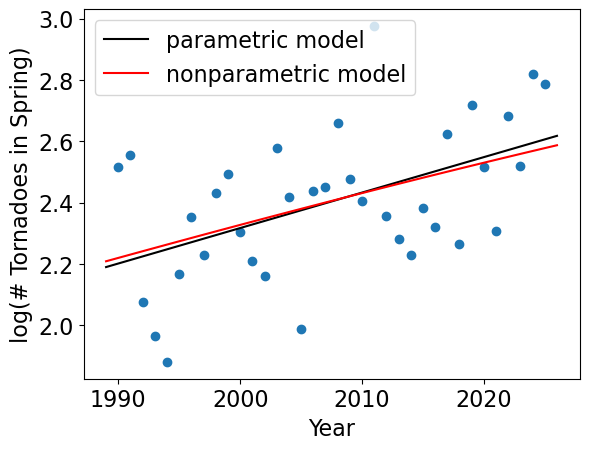

In [83]:
plt.scatter(np.array(df.year).reshape(-1,1), df.Nspring)

xs_for_plotting = np.linspace(np.array(df.year).min() - 1, np.array(df.year).max() + 1)

plt.plot(xs_for_plotting, parametric_model.predict(xs_for_plotting.reshape(-1,1)), 'k', label = 'parametric model')
plt.plot(xs_for_plotting, nonparametric_model.predict(xs_for_plotting.reshape(-1,1)), 'r', label = 'nonparametric model')

plt.xlabel('Year')
plt.ylabel('log(# Tornadoes in Spring)')
plt.legend(loc = 'upper left')

plt.show()

The parametric and non-parametric models exhibit a similar quality of fit to the data, which we can visualize with the above plot and by comparing the MSE's.

In [80]:
d_star = parametric_mse - nonparametric_mse
print(d_star)

-0.00030019332445158087


(0.0, 400.0)

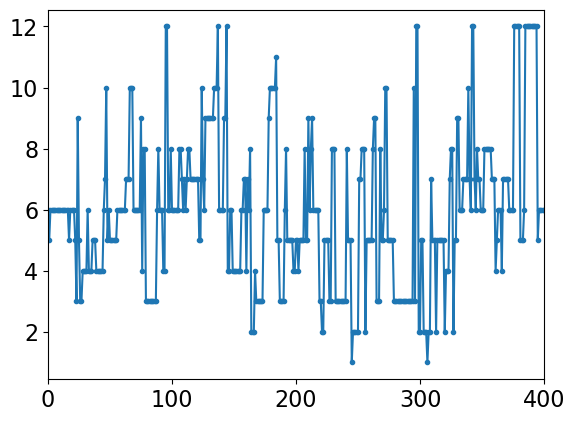

In [55]:
plt.figure()
plt.plot(np.arange(0,len(dfall)), dfall.MONTH, marker='.', linestyle='-')
plt.xlim([0,400])